# Classical Baseline Models

In [4]:
!pip install scikit-learn pandas numpy matplotlib seaborn joblib -q

In [5]:
CATEGORIES = [
    "Electronics",
    "Books",
    "Clothing_Shoes_and_Jewelry",
    "Home_and_Kitchen",
    "Sports_and_Outdoors",
]

CATEGORY_LABELS = [
    "Electronics", "Books", "Clothing", "Home & Kitchen", "Sports"
]

FILE_STEMS = {
    "Electronics":               "electronics",
    "Books":                     "books",
    "Clothing_Shoes_and_Jewelry": "clothing",
    "Home_and_Kitchen":           "home_kitchen",
    "Sports_and_Outdoors":        "sports",
}

TFIDF_MAX_FEATURES = 50_000
TFIDF_NGRAM_RANGE  = (1, 2)
RANDOM_SEED        = 104
DRIVE_BASE         = "/content/drive/MyDrive/cross-category-sentiment-robustness"

In [6]:
import os
from google.colab import drive

drive.mount("/content/drive")
DATA_DIR    = f"{DRIVE_BASE}/data"
MODELS_DIR  = f"{DRIVE_BASE}/models"
RESULTS_DIR = f"{DRIVE_BASE}/results"
FIGURES_DIR = f"{DRIVE_BASE}/figures"

for d in [MODELS_DIR, RESULTS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

Mounted at /content/drive


In [7]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [8]:
def load_split(stem: str, split: str) -> pd.DataFrame:
    path = f"{DATA_DIR}/{stem}_{split}.csv"
    df = pd.read_csv(path)
    df["text"] = df["text"].fillna("").str.lower().str.strip()
    return df

train_data = {cat: load_split(FILE_STEMS[cat], "train") for cat in CATEGORIES}
test_data  = {cat: load_split(FILE_STEMS[cat], "test")  for cat in CATEGORIES}

print("Loaded all splits.")
for cat in CATEGORIES:
    print(f"  {cat}: train={len(train_data[cat])}, test={len(test_data[cat])}")

Loaded all splits.
  Electronics: train=3500, test=750
  Books: train=3500, test=750
  Clothing_Shoes_and_Jewelry: train=3500, test=750
  Home_and_Kitchen: train=3500, test=750
  Sports_and_Outdoors: train=3500, test=750


In [9]:
def make_logreg(seed: int) -> LogisticRegression:
    return LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs",
                              random_state=seed, n_jobs=-1)

def make_svm(seed: int) -> SGDClassifier:
    return SGDClassifier(loss="hinge", max_iter=1000, tol=1e-3,
                         random_state=seed, n_jobs=-1)

def train_pipeline(source_cat: str, clf_name: str, seed: int):
    """Fit TF-IDF + classifier on source_cat train set. Return (vectoriser, clf)."""
    df_train = train_data[source_cat]
    vec = TfidfVectorizer(
        max_features=TFIDF_MAX_FEATURES,
        ngram_range=TFIDF_NGRAM_RANGE,
        sublinear_tf=True,
    )
    X = vec.fit_transform(df_train["text"])
    y = df_train["label"].values

    clf = make_logreg(seed) if clf_name == "logreg" else make_svm(seed)
    clf.fit(X, y)

    stem     = FILE_STEMS[source_cat]
    model_dir = f"{MODELS_DIR}/{clf_name}_{stem}"
    os.makedirs(model_dir, exist_ok=True)
    joblib.dump(vec, f"{model_dir}/tfidf_vectoriser.joblib")
    joblib.dump(clf, f"{model_dir}/{clf_name}_classifier.joblib")

    return vec, clf


def evaluate_transfer(vec, clf, target_cat: str) -> dict:
    df_test = test_data[target_cat]
    X_test  = vec.transform(df_test["text"])
    y_true  = df_test["label"].values
    y_pred  = clf.predict(X_test)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1":       f1_score(y_true, y_pred, average="macro"),
        "y_true":   y_true,
        "y_pred":   y_pred,
    }

In [10]:
results: dict[str, dict] = {"logreg": {}, "svm": {}}

for clf_name in ["logreg", "svm"]:
    print(f"Model: {clf_name.upper()}")
    for source_cat in CATEGORIES:
        print()
        print(f"Training on {source_cat} …")
        vec, clf = train_pipeline(source_cat, clf_name, RANDOM_SEED)

        results[clf_name][source_cat] = {}
        for target_cat in CATEGORIES:
            res = evaluate_transfer(vec, clf, target_cat)
            results[clf_name][source_cat][target_cat] = res
            tag = "(in-domain)" if source_cat == target_cat else ""
            print(f"  {target_cat:<35} acc={res['accuracy']:.3f}  f1={res['f1']:.3f} {tag}")

        print(f"  In-domain classification report ({source_cat}):")
        r = results[clf_name][source_cat][source_cat]
        print(classification_report(r["y_true"], r["y_pred"],
                                    target_names=["negative", "positive"]))

Model: LOGREG

Training on Electronics …
  Electronics                         acc=0.904  f1=0.904 (in-domain)
  Books                               acc=0.821  f1=0.821 
  Clothing_Shoes_and_Jewelry          acc=0.847  f1=0.846 
  Home_and_Kitchen                    acc=0.895  f1=0.895 
  Sports_and_Outdoors                 acc=0.885  f1=0.885 
  In-domain classification report (Electronics):
              precision    recall  f1-score   support

    negative       0.89      0.93      0.91       375
    positive       0.92      0.88      0.90       375

    accuracy                           0.90       750
   macro avg       0.90      0.90      0.90       750
weighted avg       0.90      0.90      0.90       750


Training on Books …
  Electronics                         acc=0.805  f1=0.803 
  Books                               acc=0.912  f1=0.912 (in-domain)
  Clothing_Shoes_and_Jewelry          acc=0.795  f1=0.792 
  Home_and_Kitchen                    acc=0.809  f1=0.808 
  Sports_

In [11]:
def build_matrix(clf_name: str, metric: str = "accuracy") -> pd.DataFrame:
    mat = pd.DataFrame(
        index=CATEGORIES, columns=CATEGORIES, dtype=float
    )
    for src in CATEGORIES:
        for tgt in CATEGORIES:
            mat.loc[src, tgt] = results[clf_name][src][tgt][metric]
    mat.index   = CATEGORY_LABELS
    mat.columns = CATEGORY_LABELS
    return mat

logreg_acc = build_matrix("logreg", "accuracy")
svm_acc    = build_matrix("svm",    "accuracy")
logreg_f1  = build_matrix("logreg", "f1")
svm_f1     = build_matrix("svm",    "f1")

logreg_acc.to_csv(f"{RESULTS_DIR}/baseline_transfer_matrix_logreg.csv")
svm_acc.to_csv(f"{RESULTS_DIR}/baseline_transfer_matrix_svm.csv")

print("Transfer matrices saved.")
print("LogReg accuracy matrix:")
print(logreg_acc.to_string())

Transfer matrices saved.
LogReg accuracy matrix:
                Electronics     Books  Clothing  Home & Kitchen    Sports
Electronics        0.904000  0.821333  0.846667        0.894667  0.885333
Books              0.805333  0.912000  0.794667        0.809333  0.817333
Clothing           0.853333  0.790667  0.890667        0.890667  0.869333
Home & Kitchen     0.840000  0.773333  0.872000        0.908000  0.852000
Sports             0.888000  0.826667  0.858667        0.889333  0.900000


## Visualisation: Transfer matrix heatmaps

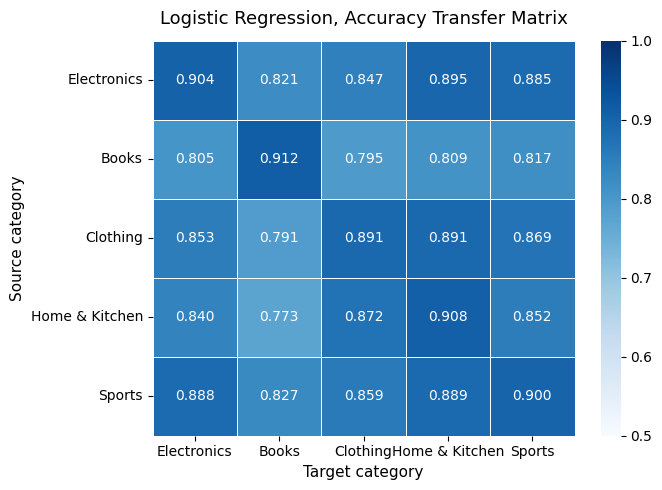

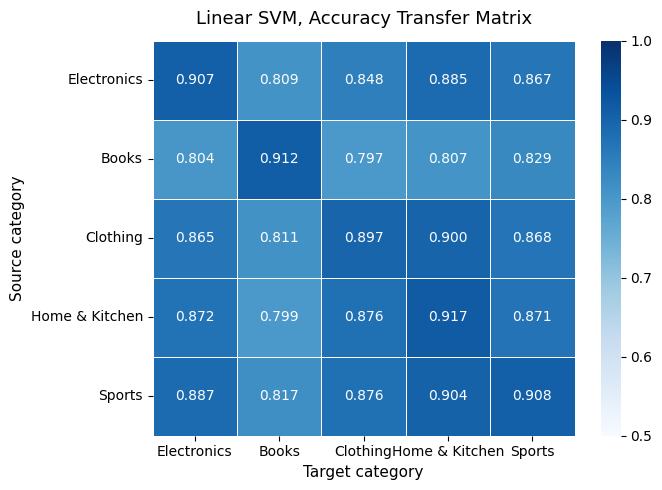

In [12]:
def plot_heatmap(mat: pd.DataFrame, title: str, filename: str):
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        mat.astype(float), annot=True, fmt=".3f",
        cmap="Blues", vmin=0.5, vmax=1.0,
        linewidths=0.5, ax=ax,
        xticklabels=mat.columns, yticklabels=mat.index,
    )
    ax.set_xlabel("Target category", fontsize=11)
    ax.set_ylabel("Source category", fontsize=11)
    ax.set_title(title, fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{filename}", dpi=150)
    plt.show()

plot_heatmap(logreg_acc, "Logistic Regression, Accuracy Transfer Matrix", "heatmap_logreg.png")
plot_heatmap(svm_acc,    "Linear SVM, Accuracy Transfer Matrix",          "heatmap_svm.png")

## Visualisation: In-domain vs average cross-domain accuracy

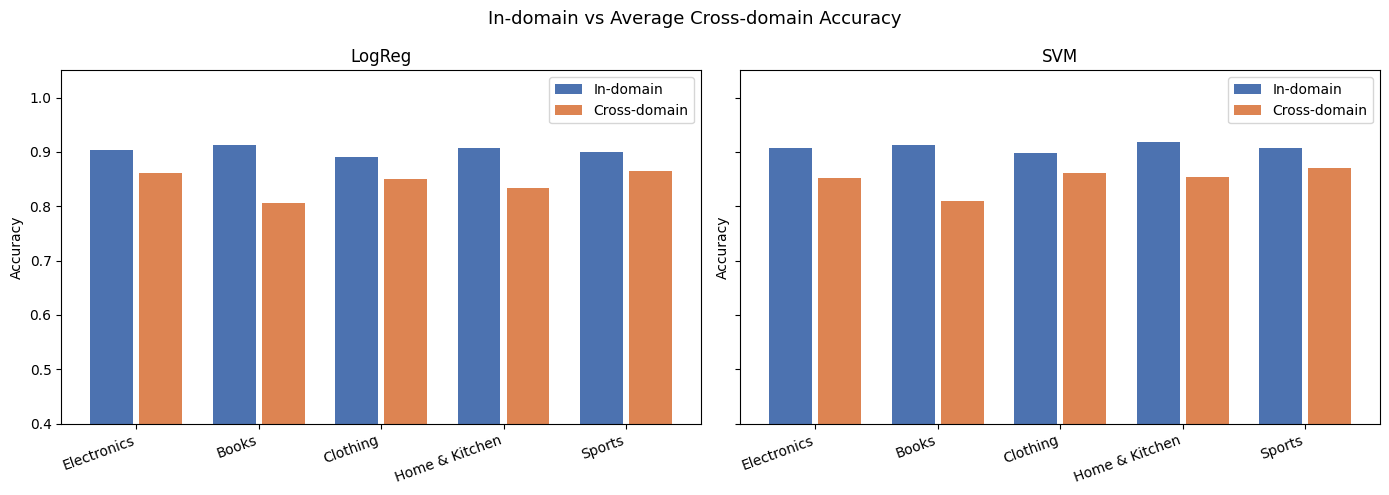

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (clf_name, mat) in zip(axes, [("LogReg", logreg_acc), ("SVM", svm_acc)]):
    n = len(CATEGORY_LABELS)
    x = np.arange(n)
    in_domain    = [mat.iloc[i, i]                         for i in range(n)]
    cross_domain = [(mat.iloc[i].sum() - mat.iloc[i, i]) / (n - 1) for i in range(n)]

    ax.bar(x - 0.2, in_domain,    0.35, label="In-domain",    color="#4c72b0")
    ax.bar(x + 0.2, cross_domain, 0.35, label="Cross-domain", color="#dd8452")
    ax.set_xticks(x)
    ax.set_xticklabels(CATEGORY_LABELS, rotation=20, ha="right")
    ax.set_ylim(0.4, 1.05)
    ax.set_ylabel("Accuracy")
    ax.set_title(clf_name)
    ax.legend()

fig.suptitle("In-domain vs Average Cross-domain Accuracy", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/accuracy_comparison_bar_baselines.png", dpi=150)
plt.show()

## Degradation summary

In [14]:
for clf_name, mat in [("LogReg", logreg_acc), ("SVM", svm_acc)]:
    print()
    print(clf_name)
    print(f"  Average in-domain accuracy:    {np.diag(mat.values.astype(float)).mean():.3f}")
    off = []
    for i in range(len(CATEGORY_LABELS)):
        for j in range(len(CATEGORY_LABELS)):
            if i != j:
                off.append(float(mat.iloc[i, j]))
    print(f"  Average cross-domain accuracy: {np.mean(off):.3f}")
    print(f"  Average degradation:           {np.diag(mat.values.astype(float)).mean() - np.mean(off):.3f}")


LogReg
  Average in-domain accuracy:    0.903
  Average cross-domain accuracy: 0.844
  Average degradation:           0.059

SVM
  Average in-domain accuracy:    0.908
  Average cross-domain accuracy: 0.850
  Average degradation:           0.059
